In [1]:
import json
import pandas as pd


def analyze_hr_zones(file_path):
    # Load data from local Excel file
    df = pd.read_excel(file_path)

    # Filter strictly by running activities
    df_running = df[df["Activity Type"].str.lower() == "running"].copy()

    # Dictionary to aggregate total time in each zone (in seconds)
    total_zones_duration = {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}

    for idx, row in df_running.iterrows():
        hz_data = row["HR Zones"]

        # Skip empty or invalid rows
        if pd.isna(hz_data) or not isinstance(hz_data, str):
            continue

        try:
            # Parse JSON string containing heart rate zone data
            zones_list = json.loads(hz_data)
            for zone_info in zones_list:
                z_num = zone_info.get("zoneNumber")
                secs = zone_info.get("secsInZone", 0.0)

                if z_num in total_zones_duration:
                    total_zones_duration[z_num] += secs
        except (json.JSONDecodeError, TypeError):
            continue

    # Print analysis results
    print("=== HEART RATE ZONES ANALYSIS (ALL RUNNING ACTIVITIES) ===")
    total_secs_all_zones = sum(total_zones_duration.values())

    for zone, total_seconds in total_zones_duration.items():
        minutes = total_seconds / 60
        percentage = (
            (total_seconds / total_secs_all_zones * 100)
            if total_secs_all_zones > 0
            else 0
        )
        print(
            f"Zone {zone}: {total_seconds:,.1f} sec | {minutes:.1f} min | {percentage:.1f}%"
        )


# Run analysis on local file
analyze_hr_zones("../data/Running stats.xlsx")

=== HEART RATE ZONES ANALYSIS (ALL RUNNING ACTIVITIES) ===
Zone 1: 10,418.1 sec | 173.6 min | 6.2%
Zone 2: 42,820.7 sec | 713.7 min | 25.7%
Zone 3: 61,034.6 sec | 1017.2 min | 36.6%
Zone 4: 30,678.4 sec | 511.3 min | 18.4%
Zone 5: 21,957.6 sec | 366.0 min | 13.2%


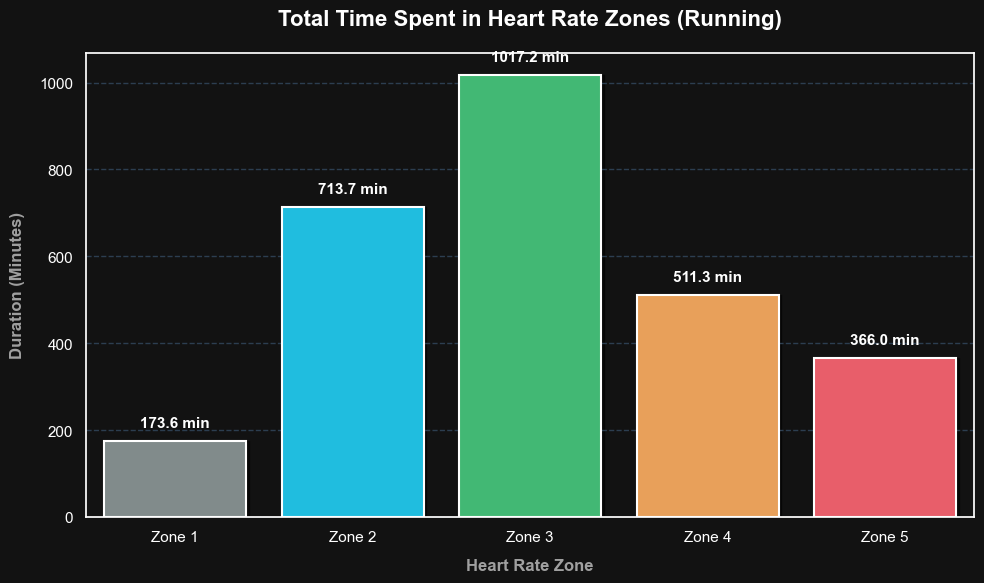

In [2]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load data from local Excel file
file_path = "../data/Running stats.xlsx"
df = pd.read_excel(file_path)
df_running = df[df["Activity Type"].str.lower() == "running"].copy()

# Dictionary to aggregate total time in each zone (in seconds)
total_zones_duration = {1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0}

for idx, row in df_running.iterrows():
    hz_data = row["HR Zones"]
    if pd.isna(hz_data) or not isinstance(hz_data, str):
        continue
    try:
        # Parse JSON string containing heart rate zone data
        zones_list = json.loads(hz_data)
        for zone_info in zones_list:
            z_num = zone_info.get("zoneNumber")
            secs = zone_info.get("secsInZone", 0.0)
            if z_num in total_zones_duration:
                total_zones_duration[z_num] += secs
    except (json.JSONDecodeError, TypeError):
        continue

# Create a DataFrame for plotting
plot_data = pd.DataFrame(
    {
        "Zone": [f"Zone {z}" for z in total_zones_duration.keys()],
        "Minutes": [secs / 60 for secs in total_zones_duration.values()],
    }
)

# Use dark background style
plt.style.use("dark_background")

# Set Seaborn theme with custom dark styling
sns.set_theme(
    style="darkgrid",
    rc={
        "grid.color": "#2c3e50",
        "grid.linestyle": "--",
        "axes.facecolor": "#121212",
        "figure.facecolor": "#121212",
        "text.color": "#ffffff",
        "axes.labelcolor": "#ffffff",
        "xtick.color": "#ffffff",
        "ytick.color": "#ffffff",
    },
)

fig, ax = plt.subplots(figsize=(10, 6), facecolor="#121212")

# Garmin HR Zone colors (optimized for glowing on dark background)
glowing_palette = ["#7f8c8d", "#00d2ff", "#2ecc71", "#ff9f43", "#ff4757"]

# Plot the bars with white borders for outline glow
bars = sns.barplot(
    x="Zone",
    y="Minutes",
    data=plot_data,
    palette=glowing_palette,
    hue="Zone",
    legend=False,
    edgecolor="#ffffff",
    linewidth=1.5,
    ax=ax,
)

# Add a subtle offset shadow patch behind each bar
for bar in bars.patches[:5]:
    x = bar.get_x()
    w = bar.get_width()
    h = bar.get_height()
    shadow = plt.Rectangle(
        (x + 0.015, 0),
        w,
        h,
        color="#000000",
        alpha=0.5,
        zorder=bar.get_zorder() - 1,
    )
    ax.add_patch(shadow)

# Customize title and labels
plt.title(
    "Total Time Spent in Heart Rate Zones (Running)",
    fontsize=16,
    fontweight="bold",
    color="#ffffff",
    pad=20,
)
plt.xlabel(
    "Heart Rate Zone",
    fontsize=12,
    fontweight="bold",
    color="#a0a0a0",
    labelpad=10,
)
plt.ylabel(
    "Duration (Minutes)",
    fontsize=12,
    fontweight="bold",
    color="#a0a0a0",
    labelpad=10,
)

# Add duration labels on top of the bars
for bar in bars.patches[:5]:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1f} min",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color="#ffffff",
    )

# Optimize layout
plt.tight_layout()
plt.show()